*  DSC 530-T302 Data Exploration and Analysis (2263-1)
*  Week 7 and 8 Assignment
*  Paula Iman

# Chapter 5, Exercise 1-4 

Create the following visualizations using what you have learned up to this point in this book. Use the data from this chapter's data/ directory:



### Exercise 1.

Plot the rolling 20-day minimum of the Facebook closing price using pandas.

<Axes: title={'center': 'Facebook 20-day Rolling Minimum Closing Price'}, xlabel='date', ylabel='Price ($)'>

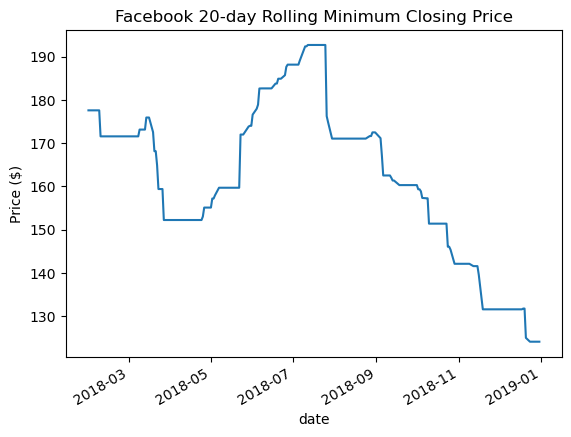

In [1]:
#Importing libraries
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fb = pd.read_csv('data/fb_stock_prices_2018.csv', index_col='date', parse_dates=True)

fb.close.rolling(20).min().plot(
    title='Facebook 20-day Rolling Minimum Closing Price', ylabel='Price ($)')


### Exercise 2.

Create a histogram and KDE of the change from open to close in the price of Facebook stock.

Text(0.5, 0, 'Change in Price ($)')

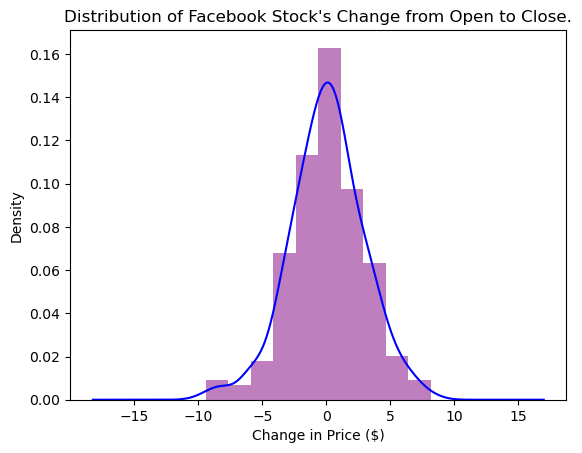

In [2]:
# First, calculate the change
fb_change = fb.close - fb.open

# Plotting the histogram for change
ax = fb_change.plot(kind='hist', density=True, color='purple', alpha=0.5)

#Plotting the KDE on the same axis
fb_change.plot(
    ax=ax, kind='kde', color='blue', 
    title='Distribution of Facebook Stock\'s Change from Open to Close.'
)
plt.xlabel('Change in Price ($)') 

### Exercise 3.

Using the earthquake data, create box plots for the magnitudes of each magType used in Indonesia.

Text(0, 0.5, 'Magnitude')

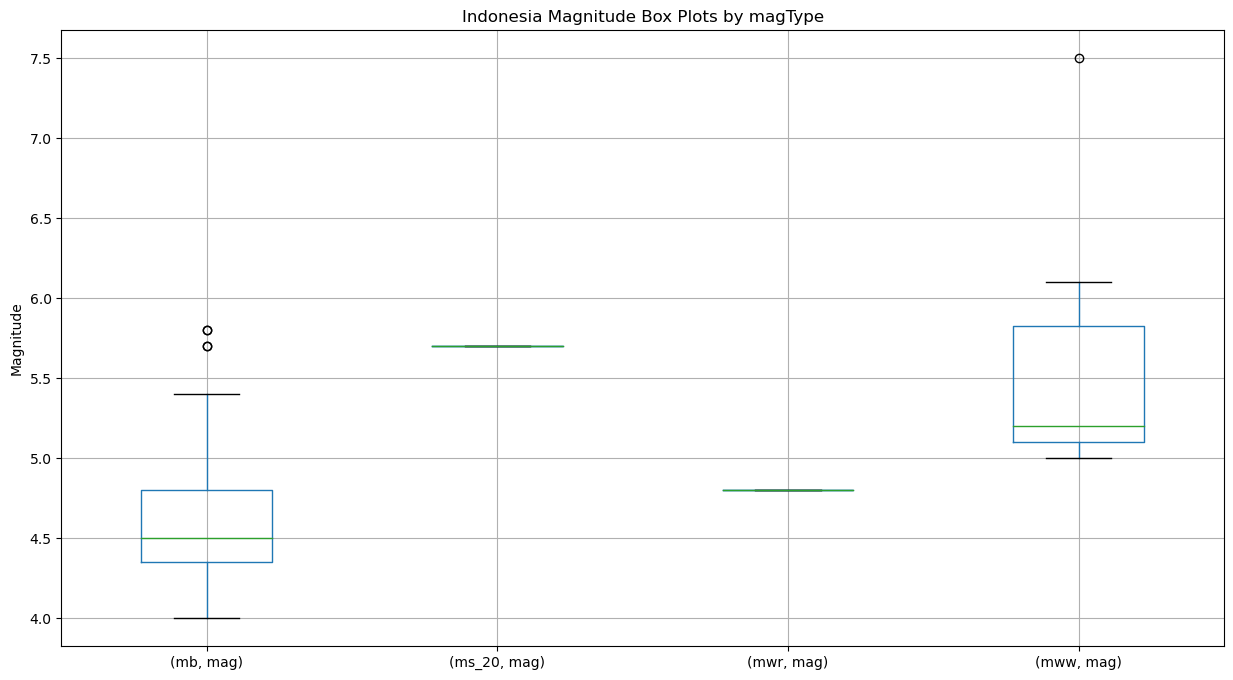

In [3]:
quakes = pd.read_csv('data/earthquakes.csv')

#Filtering for Indonesia and selecting columns 'mag' and 'magType', groping by 'magType'
quakes[quakes.parsed_place == 'Indonesia'][['mag', 'magType']].groupby('magType').boxplot(
    figsize=(15,8),
    subplots=False
)
plt.title('Indonesia Magnitude Box Plots by magType')
plt.ylabel('Magnitude')

### Exercise 4.

Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook. This should be a single line.

Text(0.5, 0, 'date')

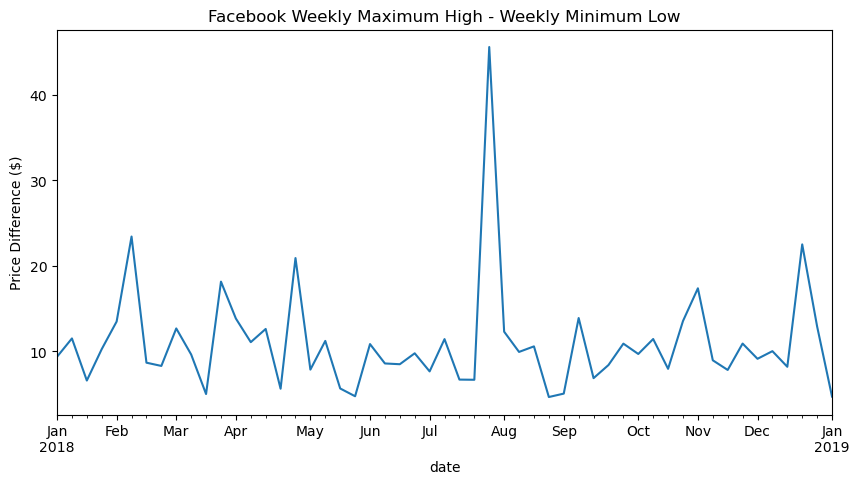

In [4]:
# resampling to weekly ('W') values and finding max high and min low
weekly_range = fb.resample('W').agg({'high': 'max', 'low': 'min'})

#Subtracting minimum low from maximum high
(weekly_range['high'] - weekly_range['low']).plot(
    kind='line',
    figsize=(10, 5),
    title='Facebook Weekly Maximum High - Weekly Minimum Low',
    ylabel='Price Difference ($)'
)

plt.xlabel('date')


# Chapter 6, Exercise 1-2 

Create the following visualizations using what we have learned so far in this book and the data from this chapter. Be sure to add titles, axis labels, and legends (where appropriate) to the plots:



### Exercise 1.

Using Seaborn, create a heatmap to visualize the correlation coefficients between earthquake magnitude and whether there was a tsunami for earthquakes measured with the mb magnitude type.



<function matplotlib.pyplot.show(close=None, block=None)>

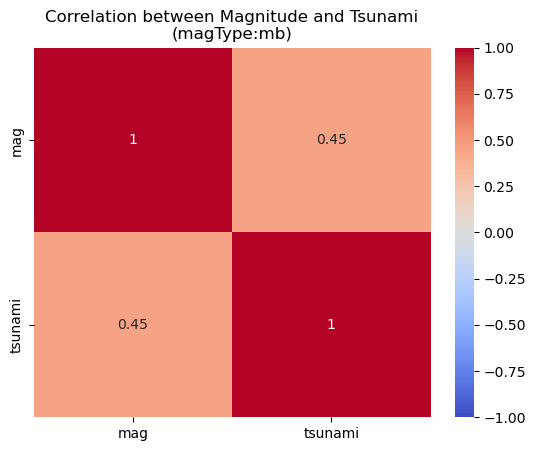

In [5]:
#importing seaborn, Matplotlib, and data.
import seaborn as sns
import matplotlib.pyplot as plt 
quakes = pd.read_csv('data/earthquakes.csv')

#Filtering for 'mb' magnitude type
mb_quakes = quakes.query('magType == "mb"')[['mag', 'tsunami']]

#Correlation matrix
correlation_matrix = mb_quakes.corr()

#Creating heatmap
sns.heatmap(correlation_matrix, annot=True,center=0,vmin=-1, vmax=1, cmap = ('coolwarm'))

#Title
plt.title('Correlation between Magnitude and Tsunami\n(magType:mb)')
plt.show

### Exercise 2.

Create a box plot of Facebook volume traded and closing prices and draw reference lines for the bounds of a Tukey fence with a multiplier of 1.5. The bounds will be at Q1 − 1.5 × IQR and Q3 + 1.5 × IQR. Be sure to use the quantile() method on the data to make this easier. Pick whichever orientation you prefer for the plot, but make sure to use subplots.



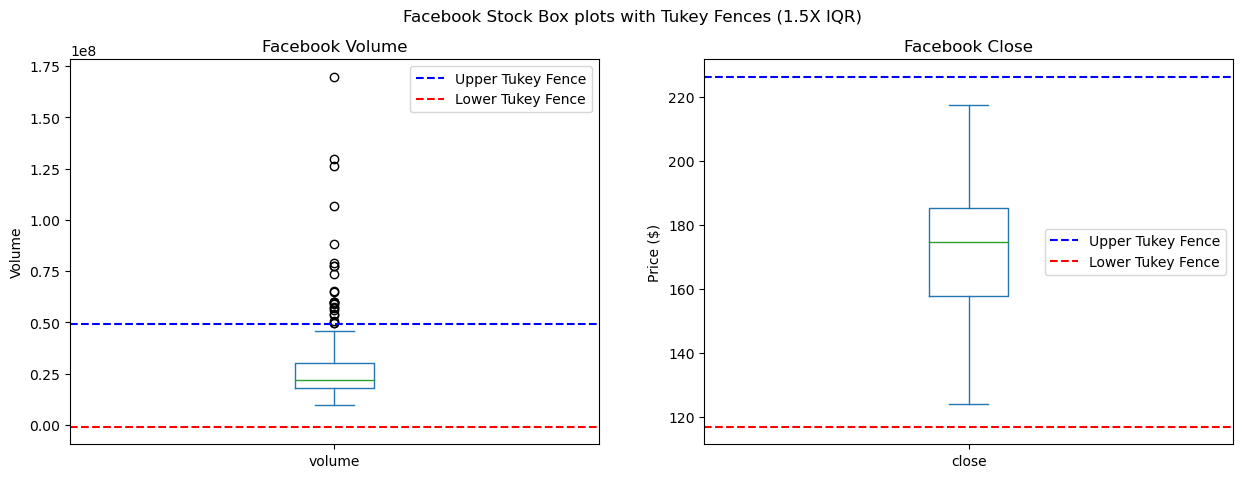

In [13]:
fb = pd.read_csv('data/fb_stock_prices_2018.csv', index_col='date', parse_dates=True)

#using the quantile() method to get Q1 (0.25) and Q3 (0.75)
stats = fb[['volume', 'close']].quantile([0.25, 0.75])

#Using subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col in zip(axes, ['volume', 'close']):
    # Tukey Fence bounds for the current column
    q1 = stats.loc[0.25, col]
    q3 = stats.loc[0.75, col]
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    #plotting the boxplot
    fb[col].plot(kind='box', ax=ax, title=f'Facebook {col.title()}')

    # Reference lines
    ax.axhline(upper_fence, color='blue', linestyle='--', label='Upper Tukey Fence')
    ax.axhline(lower_fence, color='red', linestyle='--', label='Lower Tukey Fence')
    
    #Label the y-axis and add legend
    ax.set_ylabel('Price ($)' if col == 'close' 
                  else 'Volume')
    ax.legend()

plt.suptitle('Facebook Stock Box plots with Tukey Fences (1.5X IQR)')

plt.show()